In [1]:
import h5py
import halotools
import os
import copy
import warnings
import numpy as np
import math
from astropy.modeling import Fittable1DModel, Parameter,models,fitting
import pickle
import warnings
import numpy.ma as ma
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import spearmanr,kendalltau,pearsonr
import palettable
import deepdish as dd
import matplotlib.cm as cm

from matplotlib.collections import LineCollection
from photutils.isophote import EllipseGeometry
from photutils.aperture import EllipticalAperture,EllipticalAnnulus
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from matplotlib import colors
from astroML.stats import binned_statistic_2d
from matplotlib_venn import venn2, venn3
from scipy.ndimage.filters import gaussian_filter

from astropy.utils.console import ProgressBar
from astropy.table import QTable,hstack,vstack,Column
plt.rc('text', usetex=True)
rcParams.update({'axes.linewidth': 1.5})
rcParams.update({'xtick.direction': 'in'})
rcParams.update({'ytick.direction': 'in'})
rcParams.update({'xtick.minor.visible': 'True'})
rcParams.update({'ytick.minor.visible': 'True'})
rcParams.update({'xtick.major.pad': '7.0'})
rcParams.update({'xtick.major.size': '8.0'})
rcParams.update({'xtick.major.width': '1.5'})
rcParams.update({'xtick.minor.pad': '7.0'})
rcParams.update({'xtick.minor.size': '4.0'})
rcParams.update({'xtick.minor.width': '1.5'})
rcParams.update({'ytick.major.pad': '7.0'})
rcParams.update({'ytick.major.size': '8.0'})
rcParams.update({'ytick.major.width': '1.5'})
rcParams.update({'ytick.minor.pad': '7.0'})
rcParams.update({'ytick.minor.size': '4.0'})
rcParams.update({'ytick.minor.width': '1.5'})
rcParams.update({'axes.titlepad': '10.0'})
rcParams.update({'font.size': 35})

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_50000/4041631088.py:30: DeprecationWarning: Please use `gaussian_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter


In [2]:
fig_dir="/Users/xushuo/work/Papers/CenvsSat/Figure/"
data_dir='/Users/xushuo/work/Submit/CenvsSat/Data/'

In [3]:
with open(data_dir+"galaxies_tng300_072_hmc_13_aperture_mass.txt",'rb') as f: 
    tab=pickle.load(f)
mask=(tab['proj']=='xy')
tab1=tab[mask]

In [4]:
with open(data_dir+"galaxies_tng300_072_hmc_13_richness_satellite_mass.txt",'rb') as f: 
    tab_rich0=pickle.load(f)

In [5]:
with open(data_dir+"galaxies_tng300_072_hmc_13_cylinder_richness_satellite_mass.txt",'rb') as f: 
    tab_rich=pickle.load(f)

In [6]:
tab2=hstack([tab[mask],tab_rich0[tab_rich0.colnames[2:]],tab_rich[tab_rich.colnames[2:]]])

In [7]:
df = pd.read_csv(data_dir+'tng_snap.csv')
age_tab=np.asarray(df['age'])
z_tab=np.asarray(df['redshift'])

In [8]:
cmap1=palettable.lightbartlein.diverging.BlueDarkRed18_10.mpl_colormap

In [34]:
with open(data_dir+"galaxies_tng300_072_hmc_13_stellar_mass_history_sublink_processed.txt",'rb') as f: 
    tab_smh=pickle.load(f)
with open(data_dir+"galaxies_tng300_072_hmc_13_stellar_mass_history_sublink_GrNr.txt",'rb') as f: 
    tab_grnr=pickle.load(f)
with open(data_dir+"galaxies_tng300_072_subh_hmc.txt",'rb') as f: 
    tab_subh=pickle.load(f)
with open(data_dir+"galaxies_tng300_072_mah_hmc.txt",'rb') as f: 
    tab_mah=pickle.load(f)
with open(data_dir+"galaxies_tng300_072_msath_hmc.txt",'rb') as f: 
    tab_msath=pickle.load(f)

In [10]:
mpeak_hist=[[],]
gal_num_exl=[]
for gal_num in range(3388):
    if (len(tab_mah[gal_num][0])>0):
        xdata=np.flip(np.append([72],tab_mah[gal_num][0].astype(np.int64)))
        ydata=np.flip(np.append([tab2['mass_halo'][gal_num]],tab_mah[gal_num][1]*1e10/0.6774))
        xdata0=[xdata[0],]
        ydata0=[ydata[0],]
        for i in range(1,len(xdata)):
            xdata0.append(xdata[i])
            if ydata[i]>ydata0[i-1]:
                ydata0.append(ydata[i])
            else:
                ydata0.append(ydata0[i-1])
    else:
        gal_num_exl.append(gal_num)
        xdata0=[None]
        ydata0=[None]
    mpeak_hist.append([xdata0,ydata0])
del mpeak_hist[0]

In [11]:
mask_exl=(tab2['aper_100_gal']>0)
for i in gal_num_exl:
    mask_exl=mask_exl&(tab2['gal_num']!=i)

In [12]:
mask1=(tab2['c_200c']<15)&mask_exl

In [59]:
age_list=age_tab[32:72]

In [14]:
smh_list=[[],]
for gal_num in range(3388):
    mask=(tab_smh[gal_num]['snapshot']>20)
    xdata=age_tab[tab_smh[gal_num][mask]['snapshot']]
    ydata=tab_smh[gal_num][mask]['mass_stellar']
    if np.min(xdata)<2:
        f=interp1d(xdata,ydata,kind='cubic')
        ydata0=f(age_list)
    else:
        ydata0=[None]
    smh_list.append(ydata0)
del smh_list[0]

In [37]:
tab_msath[0][0]

array([71., 70., 69., 68., 67., 66., 65., 64., 63., 62., 61., 60., 59.,
       58., 57., 56., 55., 54., 53., 52., 51., 50., 49., 48., 47., 46.,
       45., 44., 43., 42., 41., 40., 39., 38., 37., 36., 35., 34., 33.,
       32., 31., 30., 29., 28., 27., 26., 25., 24., 23., 22., 21., 20.,
       19., 18., 17., 16., 15., 14., 13., 12., 11., 10.,  9.,  8.,  7.,
        6.,  5.,  4.,  3.,  2.])

In [52]:
msath_list=[[],]
for gal_num in range(3388):
    if len(tab_msath[gal_num][0])>0:
        xdata=np.flip(np.append([72],tab_msath[gal_num][0].astype(np.int64)))
        ydata=np.flip(np.append([tab2['satellite_mass_cut_r200_8.5'][gal_num]],tab_msath[gal_num][1]))
        xdata0=xdata
        ydata0=ydata
    else:
        xdata0=[None]
        ydata0=[None]
    msath_list.append(np.asarray([xdata0,ydata0]))
del msath_list[0]

In [45]:
msath_list[0]

[array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52,
        53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69,
        70, 71, 72]),
 array([4.77821516e+07, 4.23783255e+07, 2.80734555e+08, 0.00000000e+00,
        1.77128920e+07, 1.03739931e+08, 1.33641374e+09, 1.76791917e+09,
        2.33251435e+09, 3.16685091e+09, 1.30435095e+09, 1.26477290e+09,
        5.82897878e+09, 6.41058777e+09, 8.09844631e+09, 1.74471858e+10,
        4.24343680e+10, 1.43280598e+11, 1.82127946e+11, 2.11045113e+11,
        2.67396425e+11, 3.59791783e+11, 3.21319767e+11, 4.09303670e+11,
        4.09882632e+11, 1.12427249e+12, 1.21056574e+12, 1.27808543e+12,
        1.41049180e+12, 1.49445445e+12, 1.53902942e+12, 1.44976134e+12,
        2.04761777e+12, 2.09018605e+12, 2.06463715e+12, 2.14071598e+12,
        2.16718639e+12, 2.

0

In [53]:
subh_hist=[[],]
for gal_num in range(3388):
    if (len(tab_subh[gal_num][0])>0):
        xdata=np.flip(np.append([72],tab_subh[gal_num][0].astype(np.int64)))
        ydata=np.flip(np.append([tab2['richness_cut_r200_8.5'][gal_num]],tab_subh[gal_num][1]))
        xdata0=xdata
        ydata0=ydata
    else:
        xdata0=[None]
        ydata0=[None]
    subh_hist.append(np.asarray([xdata0,ydata0]))
del subh_hist[0]

In [56]:
def stack_smh(gal_num_list):
    prof_curve=[]
    median=[]
    upper=[]
    lower=[]
    mean=[]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for gal_num in gal_num_list:
            gal_num=int(gal_num)
            if smh_list[gal_num][0]!=None:
                prof_curve.append(smh_list[gal_num])
        for i in range(len(age_list)):
            median.append(np.median(np.asarray(prof_curve).T[i]))
            upper.append(np.percentile(np.asarray(prof_curve).T[i],84))
            lower.append(np.percentile(np.asarray(prof_curve).T[i],16))
            mean.append(np.mean(np.asarray(prof_curve).T[i]))
    return np.asarray(median),np.asarray(upper),np.asarray(lower),np.asarray(mean)
def stack_mah(gal_num_list):
    prof_curve=[]
    median=[]
    upper=[]
    lower=[]
    mean=[]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for gal_num in gal_num_list:
            gal_num=int(gal_num)
            x=age_tab[mpeak_hist[gal_num][0]]
            y=np.asarray(mpeak_hist[gal_num][1])
            mask00=(x>1)
            if np.min(x[mask00])<3:
                f=interp1d(x[mask00],y[mask00],kind='cubic')
                prof_curve.append(f(age_list))
        for i in range(len(age_list)):
            median.append(np.median(np.asarray(prof_curve).T[i]))
            upper.append(np.percentile(np.asarray(prof_curve).T[i],84))
            lower.append(np.percentile(np.asarray(prof_curve).T[i],16))
            mean.append(np.mean(np.asarray(prof_curve).T[i]))
    return np.asarray(median),np.asarray(upper),np.asarray(lower),np.asarray(mean)
def stack_subh(gal_num_list):
    prof_curve=[]
    median=[]
    upper=[]
    lower=[]
    mean=[]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for gal_num in gal_num_list:
            gal_num=int(gal_num)
            if subh_hist[gal_num][0][0]==None:
                continue
            x=age_tab[subh_hist[gal_num][0].astype(np.int64)]
            y=np.asarray(subh_hist[gal_num][1])
            mask00=(x>1)
            if np.min(x[mask00])<3:
                f=interp1d(x[mask00],y[mask00],kind='cubic')
                prof_curve.append(f(age_list))
        for i in range(len(age_list)):
            median.append(np.median(np.asarray(prof_curve).T[i]))
            upper.append(np.percentile(np.asarray(prof_curve).T[i],84))
            lower.append(np.percentile(np.asarray(prof_curve).T[i],16))
            mean.append(np.mean(np.asarray(prof_curve).T[i]))
    return np.asarray(median),np.asarray(upper),np.asarray(lower),np.asarray(mean)
def stack_msath(gal_num_list):
    prof_curve=[]
    median=[]
    upper=[]
    lower=[]
    mean=[]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for gal_num in gal_num_list:
            gal_num=int(gal_num)
            if msath_list[gal_num][0][0]==None:
                continue
            x=age_tab[msath_list[gal_num][0].astype(np.int64)]
            y=np.asarray(msath_list[gal_num][1])
            mask00=(x>1)
            if np.min(x[mask00])<3:
                f=interp1d(x[mask00],y[mask00],kind='cubic')
                prof_curve.append(f(age_list))
        for i in range(len(age_list)):
            median.append(np.median(np.asarray(prof_curve).T[i]))
            upper.append(np.percentile(np.asarray(prof_curve).T[i],84))
            lower.append(np.percentile(np.asarray(prof_curve).T[i],16))
            mean.append(np.mean(np.asarray(prof_curve).T[i]))
    return np.asarray(median),np.asarray(upper),np.asarray(lower),np.asarray(mean)

In [17]:
def bootstrap_smh(gal_num_list,age_list,times=3000):
    smh_list_0=[]
    for ii in range(times):
        gal_rand=resample_list(gal_num_list)
        smh=stack_smh_mean(gal_rand)
        smh_list_0.append(smh)
    upper=[]
    lower=[]
    for j in range(len(age_list)):
        upper.append(np.percentile(np.asarray(smh_list_0).T[j],84))
        lower.append(np.percentile(np.asarray(smh_list_0).T[j],16))
    return np.asarray(upper),np.asarray(lower)


In [18]:
def topNselect(data,name,number):
    data_meta=data.group_by(name)
    data0=data_meta[-number::]
    return data0
def topNoutselect(data,name1,name2,number):
    data_meta=data.group_by(np.log10(data[name1]-data[name2]))
    data0=data_meta[-number::]
    return data0
def linear1d(x,a,b):
    return a*x+b
def mpeakfind(tab,bin_num=30):
    numb,bins=np.histogram(tab,bins=bin_num)
    max_value=max(numb)
    max_index=list(numb).index(max_value)
    mpeak=bins[max_index]
    return mpeak
def resample_list(tab):
    length=len(tab)
    list0=np.random.randint(length,size=length)
    return tab[list0]

In [75]:
mask1=(tab2['c_200c']<15)&mask_exl
name='richness_cut_r200_10'
label=r'$\log\lambda_{\log M_\star>10,R_{200}}$'
top_numb=800
ydata=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
topNout=topNoutselect(tab2[mask1],'aper_100_gal','aper_50_gal',top_numb)
mask_l=(ydata>=np.min(np.log10(topNout['aper_100_gal']-topNout['aper_50_gal'])))
xdata=np.log10(tab2[mask1][name])
mask_h1=(xdata>np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
mask_h2=(xdata==np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
index_list=np.where(mask_h2==True)[0]
true_num=top_numb-len(xdata[mask_h1])
array=np.zeros(len(index_list))
array[:true_num]=1
np.random.shuffle(array)
for j in range(len(index_list)):
    index=index_list[j]
    mask_h2[index]=mask_h2[index]&bool(array[j])
mask_h=mask_h1|mask_h2
mask_up=mask_l&(~mask_h)
mask_down=mask_h&(~mask_l)
mask_cro=mask_h&mask_l
    
up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]
up_data_gal_num=up_data['gal_num']
down_data_gal_num=down_data['gal_num']


median_smh_upp,upper_smh_upp,lower_smh_upp,mean_smh_upp=stack_smh(up_data_gal_num)
median_smh_down,upper_smh_down,lower_smh_down,mean_smh_down=stack_smh(down_data_gal_num)
median_mah_upp,upper_mah_upp,lower_mah_upp,mean_mah_upp=stack_mah(up_data_gal_num)
median_mah_down,upper_mah_down,lower_mah_down,mean_mah_down=stack_mah(down_data_gal_num)
median_subh_upp,upper_subh_upp,lower_subh_upp,mean_subh_upp=stack_subh(up_data_gal_num)
median_subh_down,upper_subh_down,lower_subh_down,mean_subh_down=stack_subh(down_data_gal_num)
median_msath_upp,upper_msath_upp,lower_msath_upp,mean_msath_upp=stack_msath(up_data_gal_num)
median_msath_down,upper_msath_down,lower_msath_down,mean_msath_down=stack_msath(down_data_gal_num)



/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_50000/3327745223.py:8: RuntimeWarning: divide by zero encountered in log10
  xdata=np.log10(tab2[mask1][name])


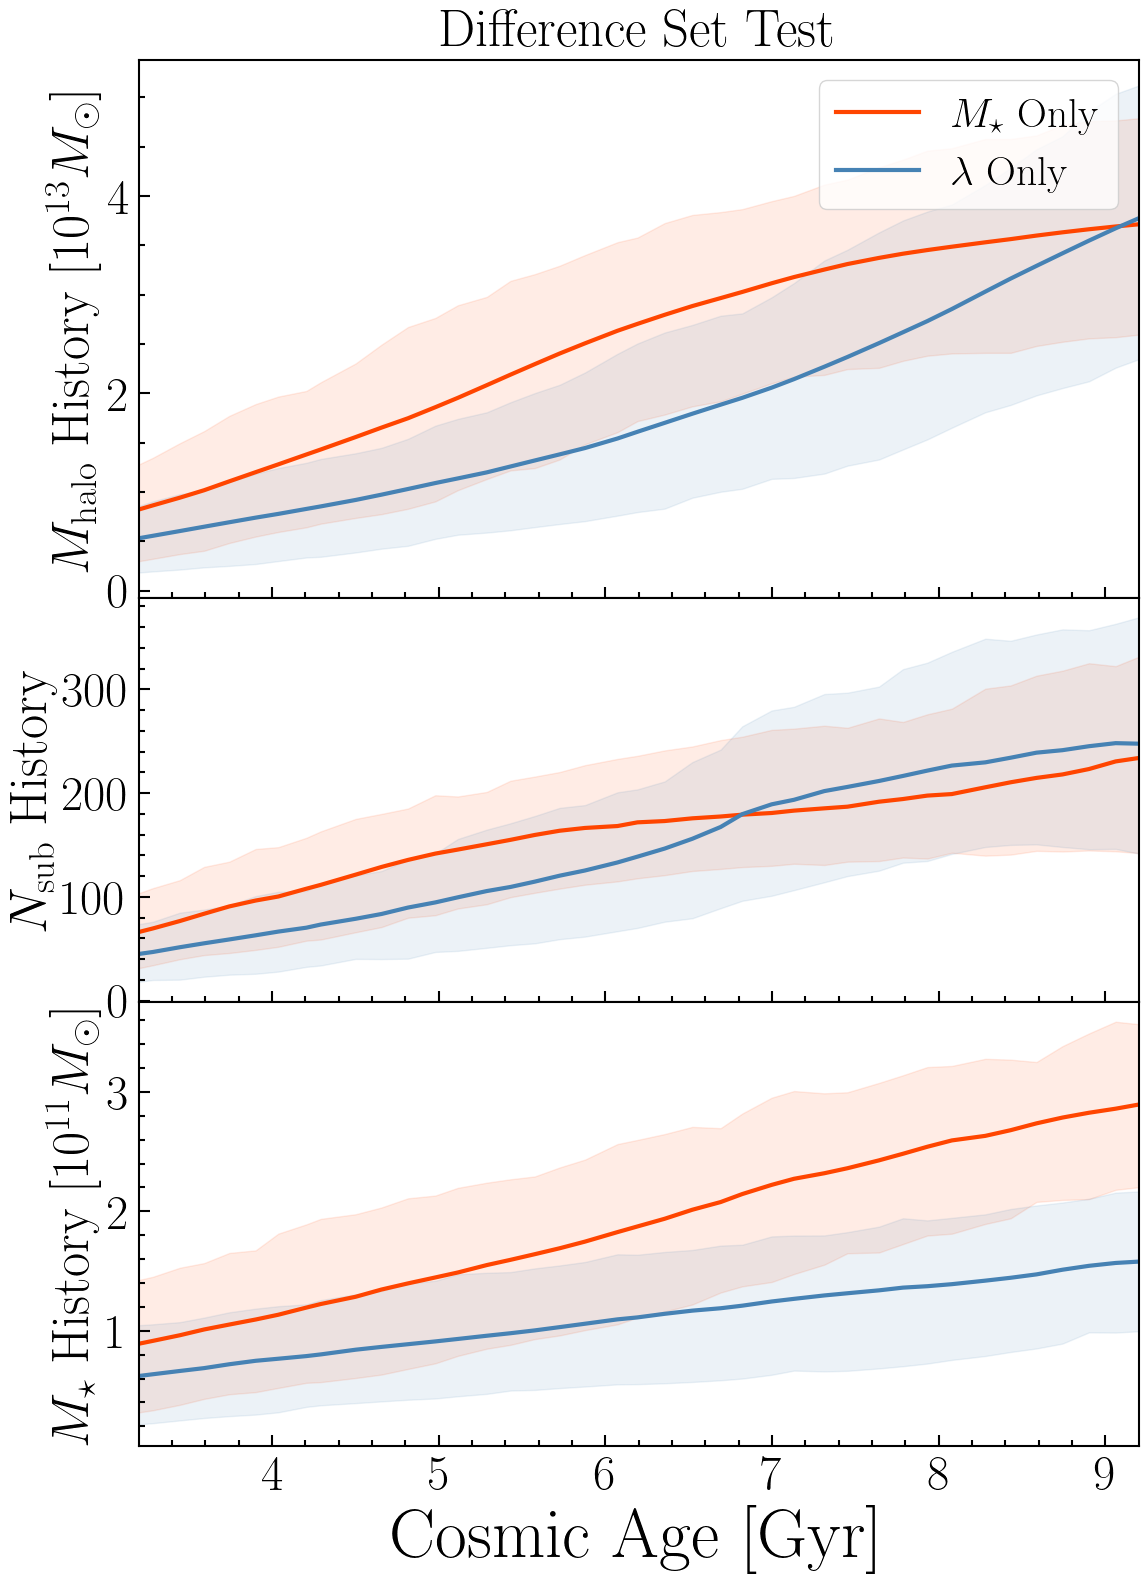

In [64]:
from matplotlib.gridspec import GridSpec
fig=plt.figure(figsize=(10,18))
gs_right = GridSpec(3, 1, left=0, right=1, hspace=0, height_ratios=(0.4,0.3,0.33))  # No vertical space


ax22= fig.add_subplot(gs_right[0])
ax21 = fig.add_subplot(gs_right[1],sharex=ax22)
ax20 = fig.add_subplot(gs_right[2],sharex=ax22)

ax20.plot(age_list,mean_smh_upp/1e11,color='orangered',lw=3,alpha=1,label=r'$M_\star$ {\rm Only}')
ax20.plot(age_list,mean_smh_down/1e11,color='steelblue',lw=3,alpha=1,label=r'$\lambda$ {\rm Only}')
ax20.fill_between(age_list,upper_smh_upp/1e11,lower_smh_upp/1e11,color='orangered',alpha=0.1)
ax20.fill_between(age_list,upper_smh_down/1e11,lower_smh_down/1e11,color='steelblue',alpha=0.1)

ax21.plot(age_list,mean_subh_upp,color='orangered',lw=3,alpha=1,label=r'$M_\star$ {\rm Only}')
ax21.plot(age_list,mean_subh_down,color='steelblue',lw=3,alpha=1,label=r'$\lambda$ {\rm Only}')
ax21.fill_between(age_list,upper_subh_upp,lower_subh_upp,color='orangered',alpha=0.1)
ax21.fill_between(age_list,upper_subh_down,lower_subh_down,color='steelblue',alpha=0.1)


ax22.plot(age_list,mean_mah_upp/1e13,color='orangered',lw=3,alpha=1,label=r'$M_\star$ {\rm Only}')
ax22.plot(age_list,mean_mah_down/1e13,color='steelblue',lw=3,alpha=1,label=r'$\lambda$ {\rm Only}')
ax22.fill_between(age_list,upper_mah_upp/1e13,lower_mah_upp/1e13,color='orangered',alpha=0.1)
ax22.fill_between(age_list,upper_mah_down/1e13,lower_mah_down/1e13,color='steelblue',alpha=0.1)

ax20.set_ylabel(r'\rm $M_\star$ {\rm History} $[10^{11} M_\odot]$', fontsize=38)
ax21.set_ylabel(r'\rm $N_{\rm sub}$ {\rm History}', fontsize=38)
ax22.set_ylabel(r'\rm $M_{\rm halo}$ {\rm History} $[10^{13} M_\odot]$', fontsize=38)
ax20.set_xlim(3.2,9.2)
ax20.set_xlabel(r'\rm Cosmic Age [Gyr]', fontsize=50)


ax22.legend(fontsize=30)
ax22.set_title(r'\rm Difference Set Test', fontsize=38)

plt.savefig(fig_dir+"Fig6.pdf",dpi=150,bbox_inches='tight')

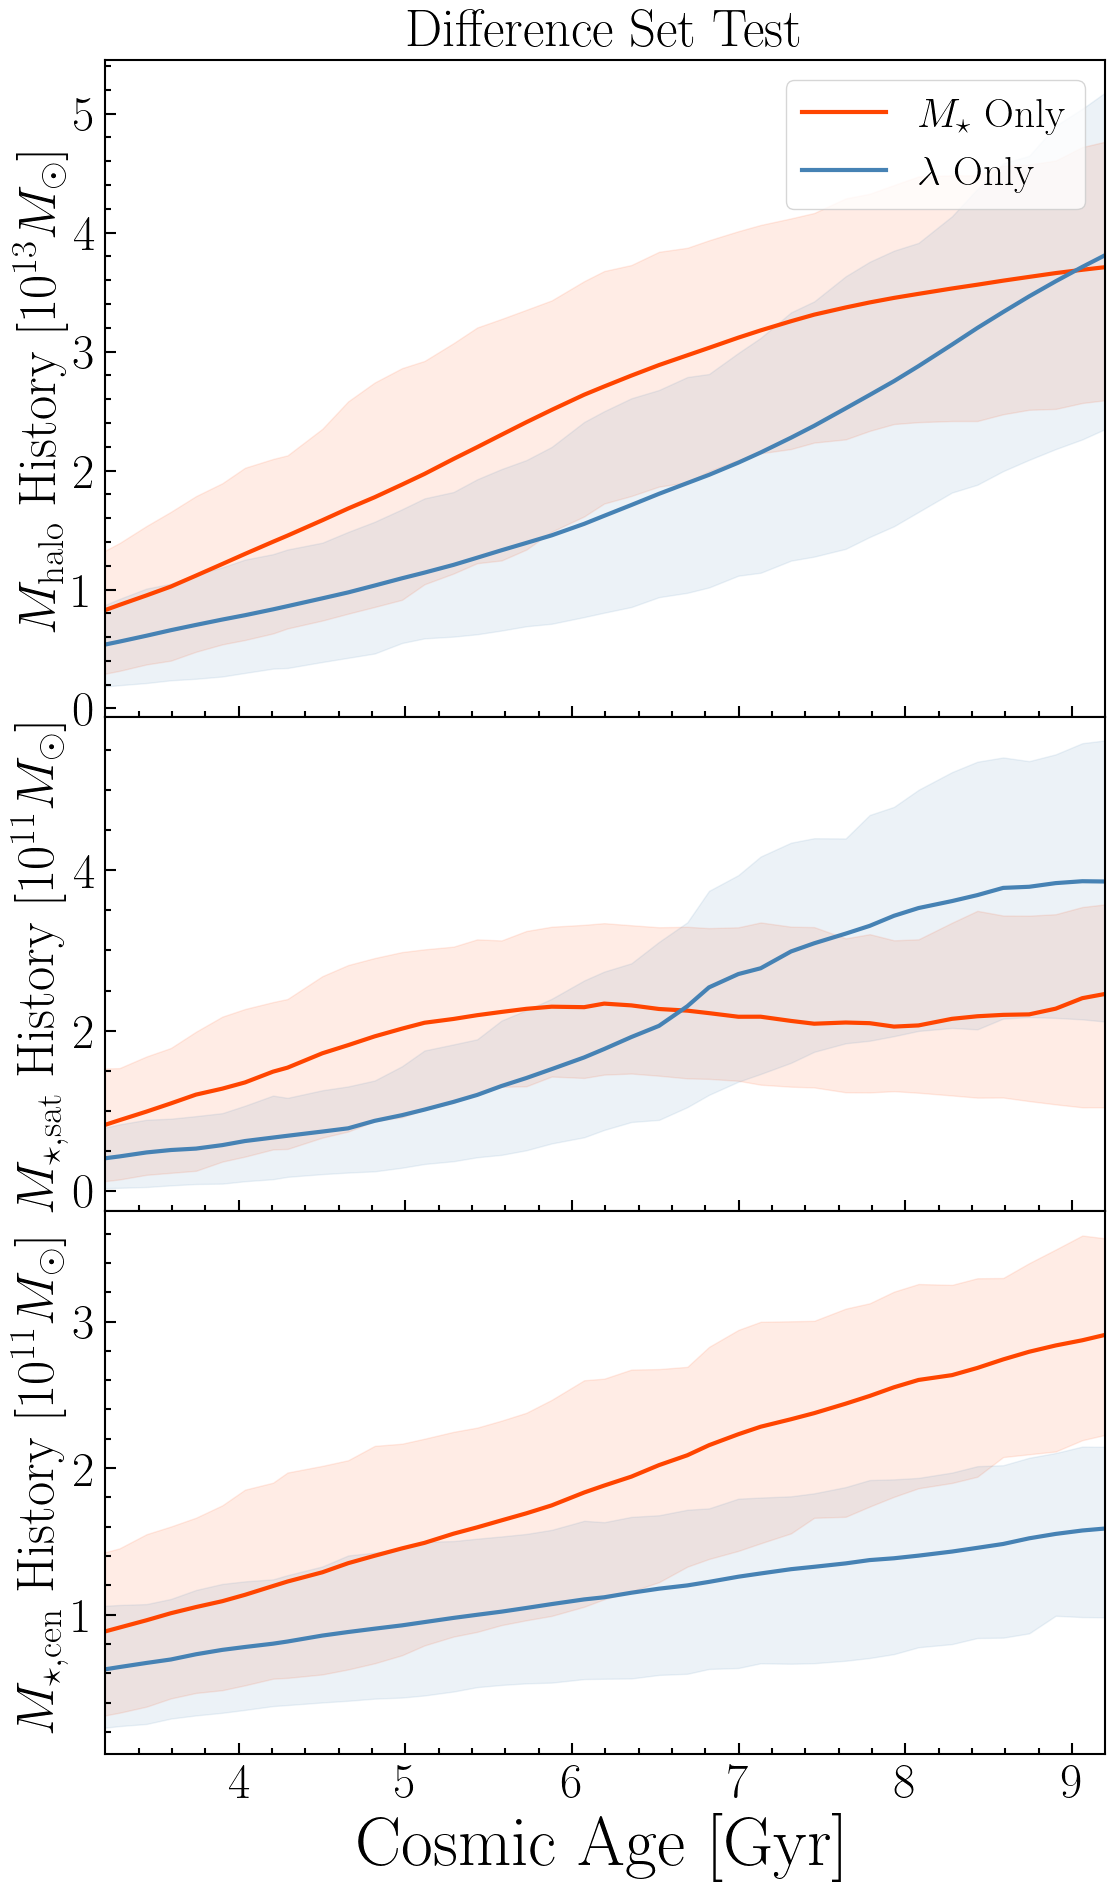

In [76]:
from matplotlib.gridspec import GridSpec
fig=plt.figure(figsize=(10,22))
gs_right = GridSpec(3, 1, left=0, right=1, hspace=0, height_ratios=(0.4,0.3,0.33))  # No vertical space


ax22= fig.add_subplot(gs_right[0])
ax21 = fig.add_subplot(gs_right[1],sharex=ax22)
ax20 = fig.add_subplot(gs_right[2],sharex=ax22)

ax20.plot(age_list,mean_smh_upp/1e11,color='orangered',lw=3,alpha=1,label=r'$M_\star$ {\rm Only}')
ax20.plot(age_list,mean_smh_down/1e11,color='steelblue',lw=3,alpha=1,label=r'$\lambda$ {\rm Only}')
ax20.fill_between(age_list,upper_smh_upp/1e11,lower_smh_upp/1e11,color='orangered',alpha=0.1)
ax20.fill_between(age_list,upper_smh_down/1e11,lower_smh_down/1e11,color='steelblue',alpha=0.1)

ax21.plot(age_list,mean_msath_upp/1e11,color='orangered',lw=3,alpha=1,label=r'$M_\star$ {\rm Only}')
ax21.plot(age_list,mean_msath_down/1e11,color='steelblue',lw=3,alpha=1,label=r'$\lambda$ {\rm Only}')
ax21.fill_between(age_list,upper_msath_upp/1e11,lower_msath_upp/1e11,color='orangered',alpha=0.1)
ax21.fill_between(age_list,upper_msath_down/1e11,lower_msath_down/1e11,color='steelblue',alpha=0.1)

ax22.plot(age_list,mean_mah_upp/1e13,color='orangered',lw=3,alpha=1,label=r'$M_\star$ {\rm Only}')
ax22.plot(age_list,mean_mah_down/1e13,color='steelblue',lw=3,alpha=1,label=r'$\lambda$ {\rm Only}')
ax22.fill_between(age_list,upper_mah_upp/1e13,lower_mah_upp/1e13,color='orangered',alpha=0.1)
ax22.fill_between(age_list,upper_mah_down/1e13,lower_mah_down/1e13,color='steelblue',alpha=0.1)

ax20.set_ylabel(r'\rm $M_{\star,\rm cen}$ {\rm History} $[10^{11} M_\odot]$', fontsize=38)
ax21.set_ylabel(r'\rm $M_{\star,\rm sat}$ {\rm History} $[10^{11} M_\odot]$', fontsize=38)
ax22.set_ylabel(r'\rm $M_{\rm halo}$ {\rm History} $[10^{13} M_\odot]$', fontsize=38)
ax20.set_xlim(3.2,9.2)
ax20.set_xlabel(r'\rm Cosmic Age [Gyr]', fontsize=50)


ax22.legend(fontsize=30)
ax22.set_title(r'\rm Difference Set Test', fontsize=38)

plt.savefig(fig_dir+"Fig6D.pdf",dpi=150,bbox_inches='tight')

In [67]:
from sklearn.linear_model import LinearRegression
def richness_top_split_test(data,name1,name2,top_numb,frac=40):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        xdata=np.log10(data[name1])
    mask_h1=(xdata>np.min(np.log10(topNselect(data,name1,top_numb)[name1])))
    mask_h2=(xdata==np.min(np.log10(topNselect(data,name1,top_numb)[name1])))
    index_list=np.where(mask_h2==True)[0]
    true_num=top_numb-len(xdata[mask_h1])
    array=np.zeros(len(index_list))
    array[:true_num]=1
    np.random.shuffle(array)
    for j in range(len(index_list)):
        index=index_list[j]
        mask_h2[index]=mask_h2[index]&bool(array[j])
    mask_h=mask_h1|mask_h2
    if 'out' in name2:
        ydata=np.log10(data['aper_100_gal']-data['aper_50_gal'])
    else:
        ydata=np.log10(data[name2])
    model=LinearRegression().fit(xdata[mask_h].reshape(-1, 1),ydata[mask_h])
    meta_data=ydata[mask_h]-model.coef_[0]*xdata[mask_h]
    mask_up=(meta_data>np.percentile(meta_data,100-frac))
    mask_down=(meta_data<np.percentile(meta_data,frac))
    up_data=data[mask_h][mask_up]
    down_data=data[mask_h][mask_down]
    up_gal_num=up_data['gal_num']
    down_gal_num=down_data['gal_num']
    return up_data,down_data, up_gal_num,down_gal_num

In [68]:
top_numb=800
name='richness_cut_r200_10'
up_data,down_data, up_data_gal_num,down_data_gal_num=richness_top_split_test(tab2[mask1],name,'out_50_100_gal',top_numb,frac=35)

In [69]:
median_smh_upp,upper_smh_upp,lower_smh_upp,mean_smh_upp=stack_smh(up_data_gal_num)
median_smh_down,upper_smh_down,lower_smh_down,mean_smh_down=stack_smh(down_data_gal_num)
median_mah_upp,upper_mah_upp,lower_mah_upp,mean_mah_upp=stack_mah(up_data_gal_num)
median_mah_down,upper_mah_down,lower_mah_down,mean_mah_down=stack_mah(down_data_gal_num)
median_subh_upp,upper_subh_upp,lower_subh_upp,mean_subh_upp=stack_subh(up_data_gal_num)
median_subh_down,upper_subh_down,lower_subh_down,mean_subh_down=stack_subh(down_data_gal_num)
median_msath_upp,upper_msath_upp,lower_msath_upp,mean_msath_upp=stack_msath(up_data_gal_num)
median_msath_down,upper_msath_down,lower_msath_down,mean_msath_down=stack_msath(down_data_gal_num)


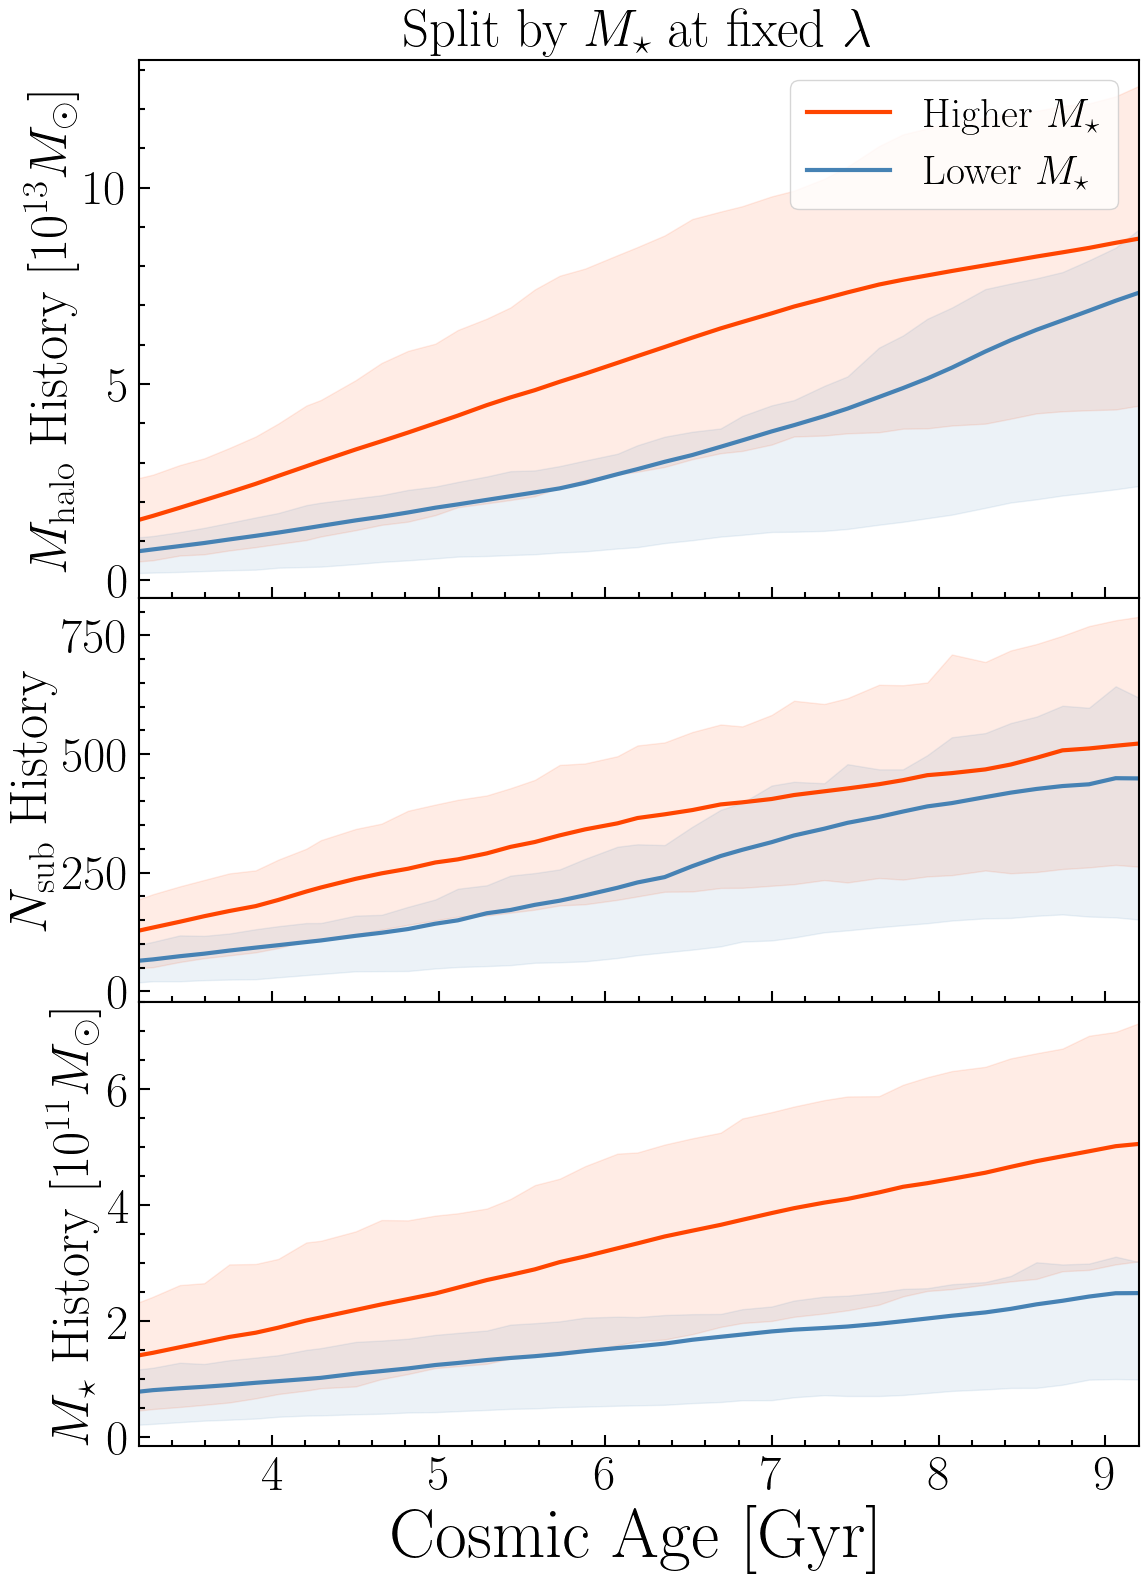

In [71]:
from matplotlib.gridspec import GridSpec
fig=plt.figure(figsize=(10,18))
gs_right = GridSpec(3, 1, left=0, right=1, hspace=0, height_ratios=(0.4,0.3,0.33))  # No vertical space


ax22= fig.add_subplot(gs_right[0])
ax21 = fig.add_subplot(gs_right[1],sharex=ax22)
ax20 = fig.add_subplot(gs_right[2],sharex=ax22)

ax20.plot(age_list,mean_smh_upp/1e11,color='orangered',lw=3,alpha=1,label=r'$M_\star$ {\rm Higher}')
ax20.plot(age_list,mean_smh_down/1e11,color='steelblue',lw=3,alpha=1,label=r'$M_\star$ {\rm Lower}')
ax20.fill_between(age_list,upper_smh_upp/1e11,lower_smh_upp/1e11,color='orangered',alpha=0.1)
ax20.fill_between(age_list,upper_smh_down/1e11,lower_smh_down/1e11,color='steelblue',alpha=0.1)

ax21.plot(age_list,mean_subh_upp,color='orangered',lw=3,alpha=1,label=r'$M_\star$ {\rm Only}')
ax21.plot(age_list,mean_subh_down,color='steelblue',lw=3,alpha=1,label=r'$\lambda$ {\rm Only}')
ax21.fill_between(age_list,upper_subh_upp,lower_subh_upp,color='orangered',alpha=0.1)
ax21.fill_between(age_list,upper_subh_down,lower_subh_down,color='steelblue',alpha=0.1)


ax22.plot(age_list,mean_mah_upp/1e13,color='orangered',lw=3,alpha=1,label=r'{\rm Higher} $M_\star$ ')
ax22.plot(age_list,mean_mah_down/1e13,color='steelblue',lw=3,alpha=1,label=r'{\rm Lower} $M_\star$ ')
ax22.fill_between(age_list,upper_mah_upp/1e13,lower_mah_upp/1e13,color='orangered',alpha=0.1)
ax22.fill_between(age_list,upper_mah_down/1e13,lower_mah_down/1e13,color='steelblue',alpha=0.1)

ax20.set_ylabel(r'\rm $M_\star$ {\rm History} $[10^{11} M_\odot]$', fontsize=38)
ax21.set_ylabel(r'\rm $N_{\rm sub}$ {\rm History}', fontsize=38)
ax22.set_ylabel(r'\rm $M_{\rm halo}$ {\rm History} $[10^{13} M_\odot]$', fontsize=38)
ax20.set_xlim(3.2,9.2)
ax20.set_xlabel(r'\rm Cosmic Age [Gyr]', fontsize=50)


ax22.legend(fontsize=30)
ax22.set_title(r'\rm Split by $M_\star$ at fixed $\lambda$', fontsize=38)

plt.savefig(fig_dir+"Fig6B.pdf",dpi=150,bbox_inches='tight')

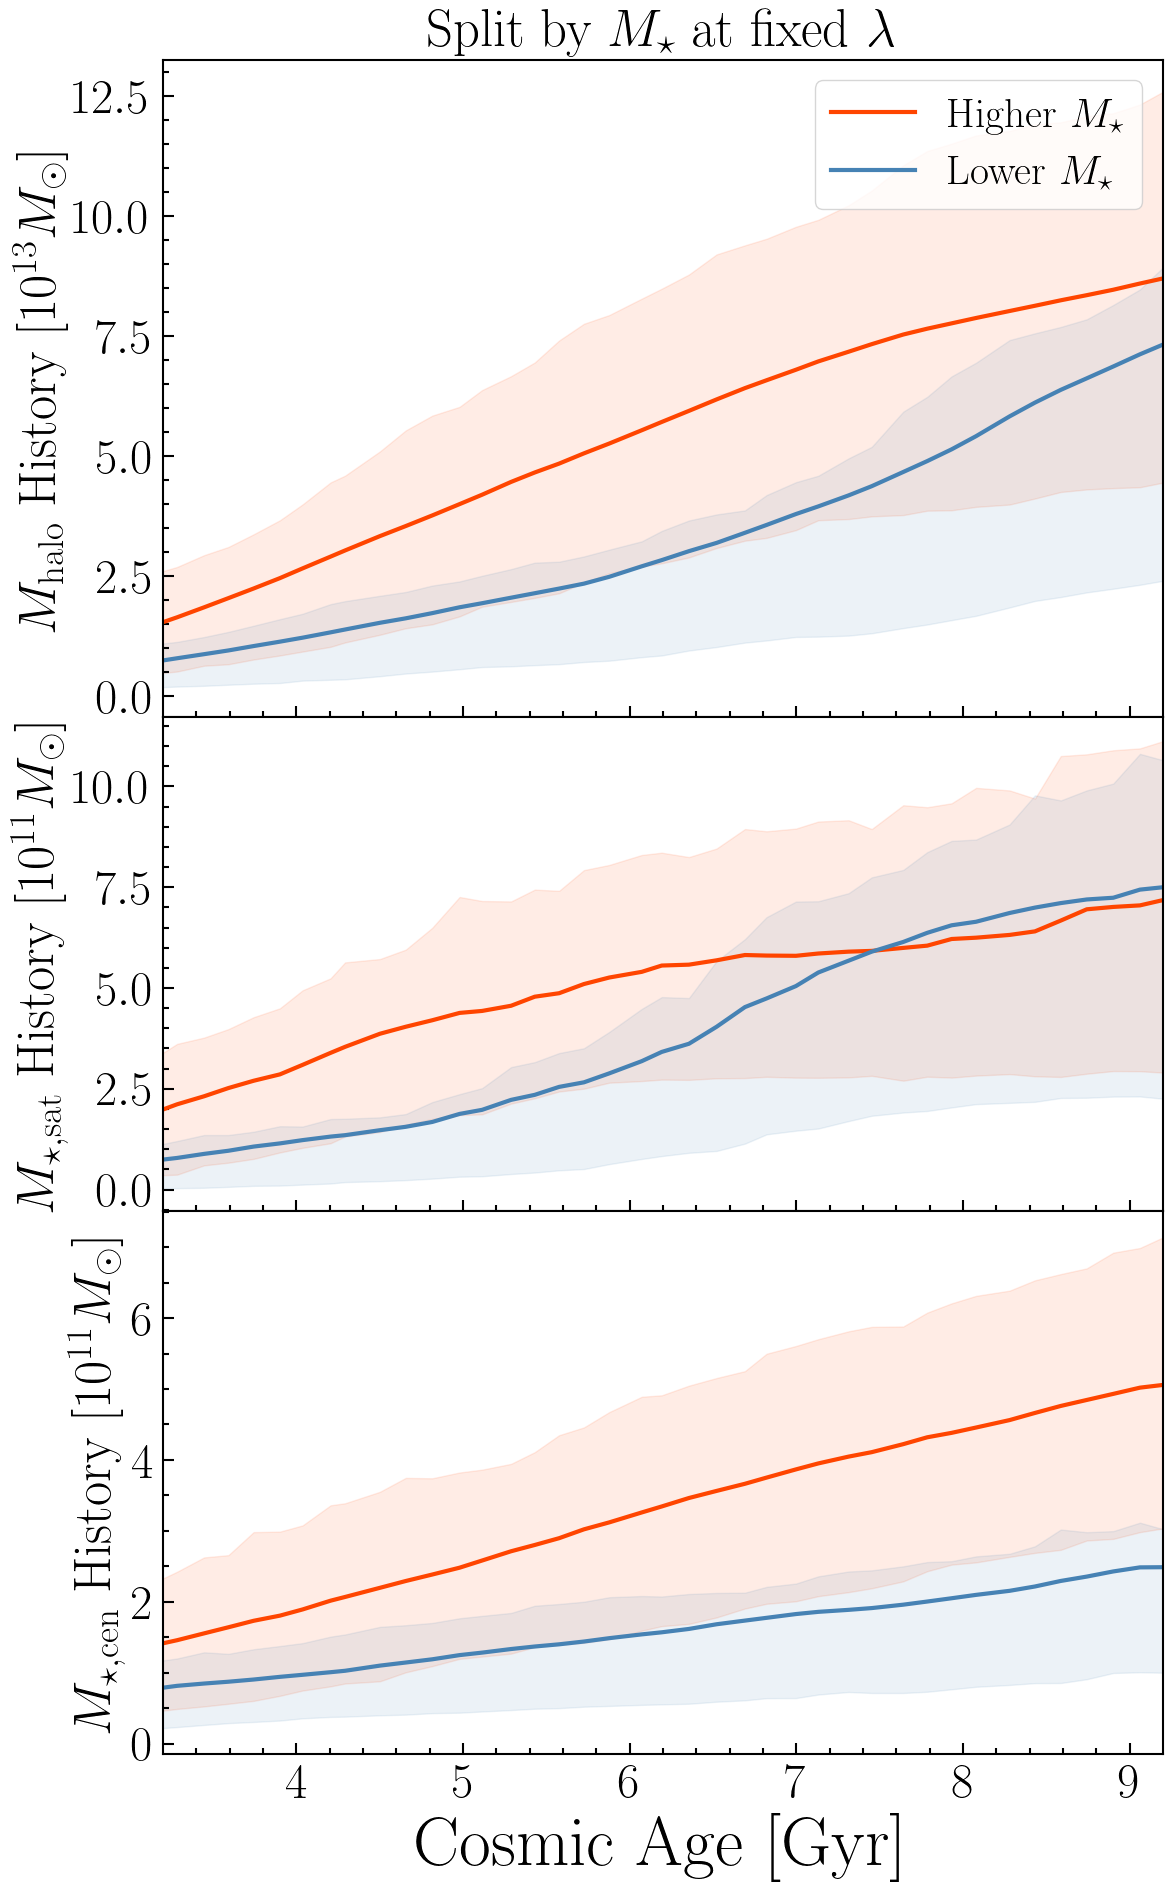

In [73]:
from matplotlib.gridspec import GridSpec
fig=plt.figure(figsize=(10,22))
gs_right = GridSpec(3, 1, left=0, right=1, hspace=0, height_ratios=(0.4,0.3,0.33))  # No vertical space


ax22= fig.add_subplot(gs_right[0])
ax21 = fig.add_subplot(gs_right[1],sharex=ax22)
ax20 = fig.add_subplot(gs_right[2],sharex=ax22)

ax20.plot(age_list,mean_smh_upp/1e11,color='orangered',lw=3,alpha=1,label=r'$M_\star$ {\rm Higher}')
ax20.plot(age_list,mean_smh_down/1e11,color='steelblue',lw=3,alpha=1,label=r'$M_\star$ {\rm Lower}')
ax20.fill_between(age_list,upper_smh_upp/1e11,lower_smh_upp/1e11,color='orangered',alpha=0.1)
ax20.fill_between(age_list,upper_smh_down/1e11,lower_smh_down/1e11,color='steelblue',alpha=0.1)

ax21.plot(age_list,mean_msath_upp/1e11,color='orangered',lw=3,alpha=1,label=r'$M_\star$ {\rm Only}')
ax21.plot(age_list,mean_msath_down/1e11,color='steelblue',lw=3,alpha=1,label=r'$\lambda$ {\rm Only}')
ax21.fill_between(age_list,upper_msath_upp/1e11,lower_msath_upp/1e11,color='orangered',alpha=0.1)
ax21.fill_between(age_list,upper_msath_down/1e11,lower_msath_down/1e11,color='steelblue',alpha=0.1)

ax22.plot(age_list,mean_mah_upp/1e13,color='orangered',lw=3,alpha=1,label=r'{\rm Higher} $M_\star$ ')
ax22.plot(age_list,mean_mah_down/1e13,color='steelblue',lw=3,alpha=1,label=r'{\rm Lower} $M_\star$ ')
ax22.fill_between(age_list,upper_mah_upp/1e13,lower_mah_upp/1e13,color='orangered',alpha=0.1)
ax22.fill_between(age_list,upper_mah_down/1e13,lower_mah_down/1e13,color='steelblue',alpha=0.1)

ax20.set_ylabel(r'\rm $M_{\star,\rm cen}$ {\rm History} $[10^{11} M_\odot]$', fontsize=38)
ax21.set_ylabel(r'\rm $M_{\star,\rm sat}$ {\rm History} $[10^{11} M_\odot]$', fontsize=38)
ax22.set_ylabel(r'\rm $M_{\rm halo}$ {\rm History} $[10^{13} M_\odot]$', fontsize=38)
ax20.set_xlim(3.2,9.2)
ax20.set_xlabel(r'\rm Cosmic Age [Gyr]', fontsize=50)


ax22.legend(fontsize=30)
ax22.set_title(r'\rm Split by $M_\star$ at fixed $\lambda$', fontsize=38)

plt.savefig(fig_dir+"Fig6E.pdf",dpi=150,bbox_inches='tight')

In [77]:

def rank_splitting_sample(xdata, ydata, zdata ,X_col, Y_col, Z_col, n_bins=5, n_sample=2,
                          X_min=None, X_max=None, X_bins=None,
                          id_each_bin=True):
    """Split sample into N_sample with fixed distribution in X, but different
    rank orders in Y.
    Parameters:
    -----------
    cat : astropy.table
        Table for input catalog
    X_col : string
        Name of the column for parameter that should have fixed distribution
    Y_col : string
        Name of the column for parameter that need to be split
    n_bins : int
        Number of bins in X
    n_sample : int
        Number of bins in Y
    X_min : float
        Minimum value of X for the binning
    X_max: float
        Maximum value of X for the binning
    X_bins : array
        Edges of X bins, provided by the users
        Usefull for irregular binnings
    Return
    ------
    """
    
    data=QTable([xdata,ydata,zdata],names=(X_col,Y_col,Z_col))

    X = data[X_col]
    X_len = len(X)
    if X_bins is None:
        if X_min is None:
            X_min = np.nanmin(X)
        if X_max is None:
            X_max = np.nanmax(X)

        msg = '# Sample size should be much larger than number of bins in X'
        assert X_len > (2 * n_bins), msg

        X_bins = np.linspace(X_min, X_max, (n_bins + 1))
    else:
        n_bins = (len(X_bins) - 1)

    # Place holder for sample ID
    data.add_column(Column(data=(np.arange(X_len) * 0),
                           name='sample_id'))
    data.add_column(Column(data=np.arange(X_len), name='index_ori'))

    # Create index array for object in each bin
    X_idxbins = np.digitize(X, X_bins, right=True)

    bin_list = []
    for ii in range(n_bins):
        subbin = data[X_idxbins == (ii + 1)]
        subbin.sort(Y_col)

        subbin_len = len(subbin)
        subbin_size = int(np.ceil(subbin_len / n_sample))

        idx_start, idx_end = 0, subbin_size
        for jj in range(n_sample):
            if idx_end > subbin_len:
                idx_end = subbin_len
            if id_each_bin:
                subbin['sample_id'][idx_start:idx_end] = ((jj + 1) +
                                                          (ii * n_sample))
            else:
                subbin['sample_id'][idx_start:idx_end] = (jj + 1)
            idx_start = idx_end
            idx_end += subbin_size

        bin_list.append(subbin)

    new_data = vstack(bin_list)

    return new_data

Text(0, 0.5, '$c_{\\rm 200c}$')

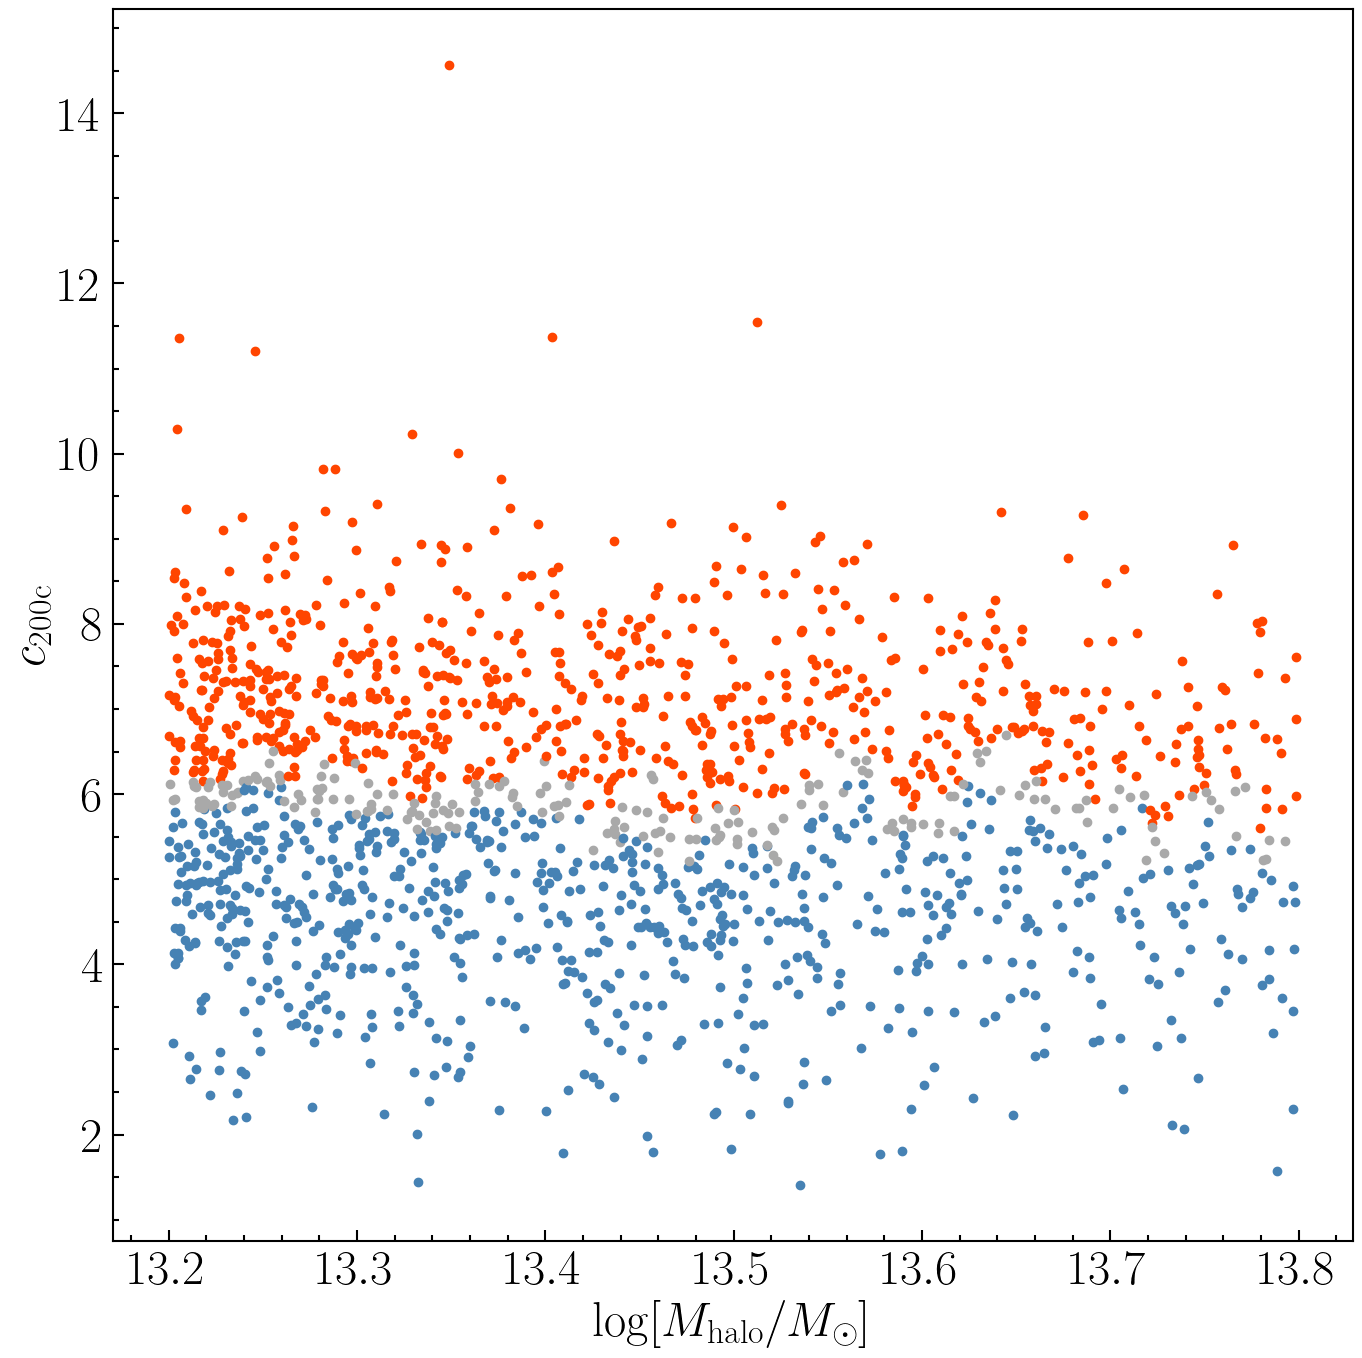

In [78]:
mask=mask_exl&(tab2['mass_halo']>10**13.2)&(tab2['mass_halo']<10**13.8)
tab=tab2
mask_c=tab['c_200c']<15
xdata=np.log10(tab[mask&mask_c]['mass_halo'])
ydata=tab[mask&mask_c]['c_200c']
zdata=tab[mask&mask_c]['gal_num']

X_col='mass_halo'
Y_col='ratio'
Z_col='gal_num'
n_bins=30
new_data=rank_splitting_sample(xdata,ydata,zdata,X_col,Y_col,Z_col,n_bins=n_bins)
fig=plt.figure(figsize=(16,16))
down_data_gal_num=np.zeros(1)
up_data_gal_num=np.zeros(1)
for i in range(1,2*n_bins+1):
    if i%2==0:
        mask_sample=(new_data['sample_id']==i)
        if len(new_data[mask_sample])>0:
            mask_1=(new_data[mask_sample]['ratio']>=(np.percentile(new_data[mask_sample]['ratio'], 10)))
            plt.scatter(new_data[mask_sample][mask_1]['mass_halo'],new_data[mask_sample][mask_1]['ratio'],color='orangered')
            up_data_gal_num=np.append(up_data_gal_num,np.asarray(new_data[mask_sample][mask_1]['gal_num']))
            plt.scatter(new_data[mask_sample][~mask_1]['mass_halo'],new_data[mask_sample][~mask_1]['ratio'],color='darkgrey')
    else:
        mask_sample=(new_data['sample_id']==i)
        if len(new_data[mask_sample])>0:
            mask_1=(new_data[mask_sample]['ratio']<=(np.percentile(new_data[mask_sample]['ratio'],90)))
            down_data_gal_num=np.append(down_data_gal_num,np.asarray(new_data[mask_sample][mask_1]['gal_num']))
            plt.scatter(new_data[mask_sample][mask_1]['mass_halo'],new_data[mask_sample][mask_1]['ratio'],color='steelblue')
            plt.scatter(new_data[mask_sample][~mask_1]['mass_halo'],new_data[mask_sample][~mask_1]['ratio'],color='darkgrey')
plt.xlabel(r'$\log[M_{\rm halo}/M_\odot]$')
plt.ylabel(r'$c_{\rm 200c}$')  


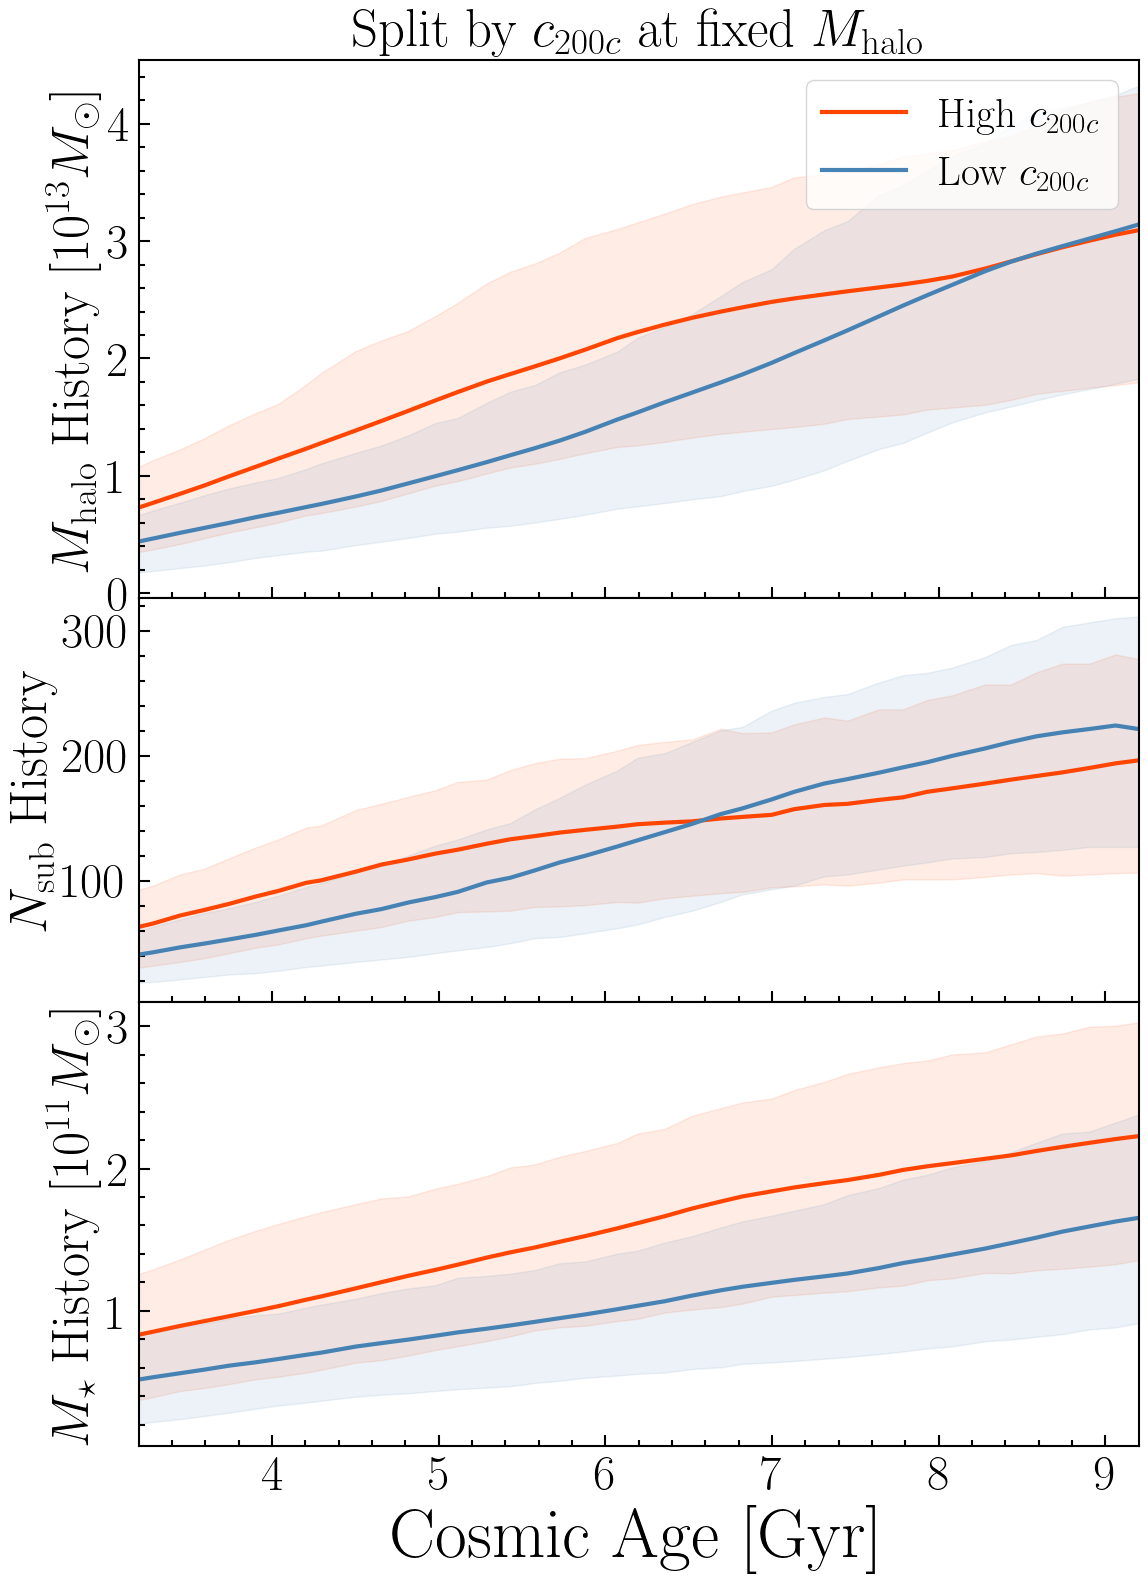

In [80]:


median_smh_upp,upper_smh_upp,lower_smh_upp,mean_smh_upp=stack_smh(up_data_gal_num)
median_smh_down,upper_smh_down,lower_smh_down,mean_smh_down=stack_smh(down_data_gal_num)
median_mah_upp,upper_mah_upp,lower_mah_upp,mean_mah_upp=stack_mah(up_data_gal_num)
median_mah_down,upper_mah_down,lower_mah_down,mean_mah_down=stack_mah(down_data_gal_num)
median_subh_upp,upper_subh_upp,lower_subh_upp,mean_subh_upp=stack_subh(up_data_gal_num)
median_subh_down,upper_subh_down,lower_subh_down,mean_subh_down=stack_subh(down_data_gal_num)
median_msath_upp,upper_msath_upp,lower_msath_upp,mean_msath_upp=stack_msath(up_data_gal_num)
median_msath_down,upper_msath_down,lower_msath_down,mean_msath_down=stack_msath(down_data_gal_num)


fig=plt.figure(figsize=(10,18))
gs_right = GridSpec(3, 1, left=0, right=1, hspace=0, height_ratios=(0.4,0.3,0.33))  # No vertical space


ax22= fig.add_subplot(gs_right[0])
ax21 = fig.add_subplot(gs_right[1],sharex=ax22)
ax20 = fig.add_subplot(gs_right[2],sharex=ax22)

ax20.plot(age_list,mean_smh_upp/1e11,color='orangered',lw=3,alpha=1)
ax20.plot(age_list,mean_smh_down/1e11,color='steelblue',lw=3,alpha=1)
ax20.fill_between(age_list,upper_smh_upp/1e11,lower_smh_upp/1e11,color='orangered',alpha=0.1)
ax20.fill_between(age_list,upper_smh_down/1e11,lower_smh_down/1e11,color='steelblue',alpha=0.1)

ax21.plot(age_list,mean_subh_upp,color='orangered',lw=3,alpha=1)
ax21.plot(age_list,mean_subh_down,color='steelblue',lw=3,alpha=1)
ax21.fill_between(age_list,upper_subh_upp,lower_subh_upp,color='orangered',alpha=0.1)
ax21.fill_between(age_list,upper_subh_down,lower_subh_down,color='steelblue',alpha=0.1)


ax22.plot(age_list,mean_mah_upp/1e13,color='orangered',lw=3,alpha=1,label=r'{\rm High} $c_{200c}$')
ax22.plot(age_list,mean_mah_down/1e13,color='steelblue',lw=3,alpha=1,label=r'{\rm Low} $c_{200c}$')
ax22.fill_between(age_list,upper_mah_upp/1e13,lower_mah_upp/1e13,color='orangered',alpha=0.1)
ax22.fill_between(age_list,upper_mah_down/1e13,lower_mah_down/1e13,color='steelblue',alpha=0.1)

ax20.set_ylabel(r'\rm $M_\star$ {\rm History} $[10^{11} M_\odot]$', fontsize=38)
ax21.set_ylabel(r'\rm $N_{\rm sub}$ {\rm History}', fontsize=38)
ax22.set_ylabel(r'\rm $M_{\rm halo}$ {\rm History} $[10^{13} M_\odot]$', fontsize=38)
ax20.set_xlim(3.2,9.2)
ax20.set_xlabel(r'\rm Cosmic Age [Gyr]', fontsize=50)
ax22.set_title(r'\rm Split by $c_{200c}$ at fixed $M_{\rm halo}$', fontsize=38)


ax22.legend(fontsize=30)


plt.savefig(fig_dir+"Fig6C.pdf",dpi=150,bbox_inches='tight')

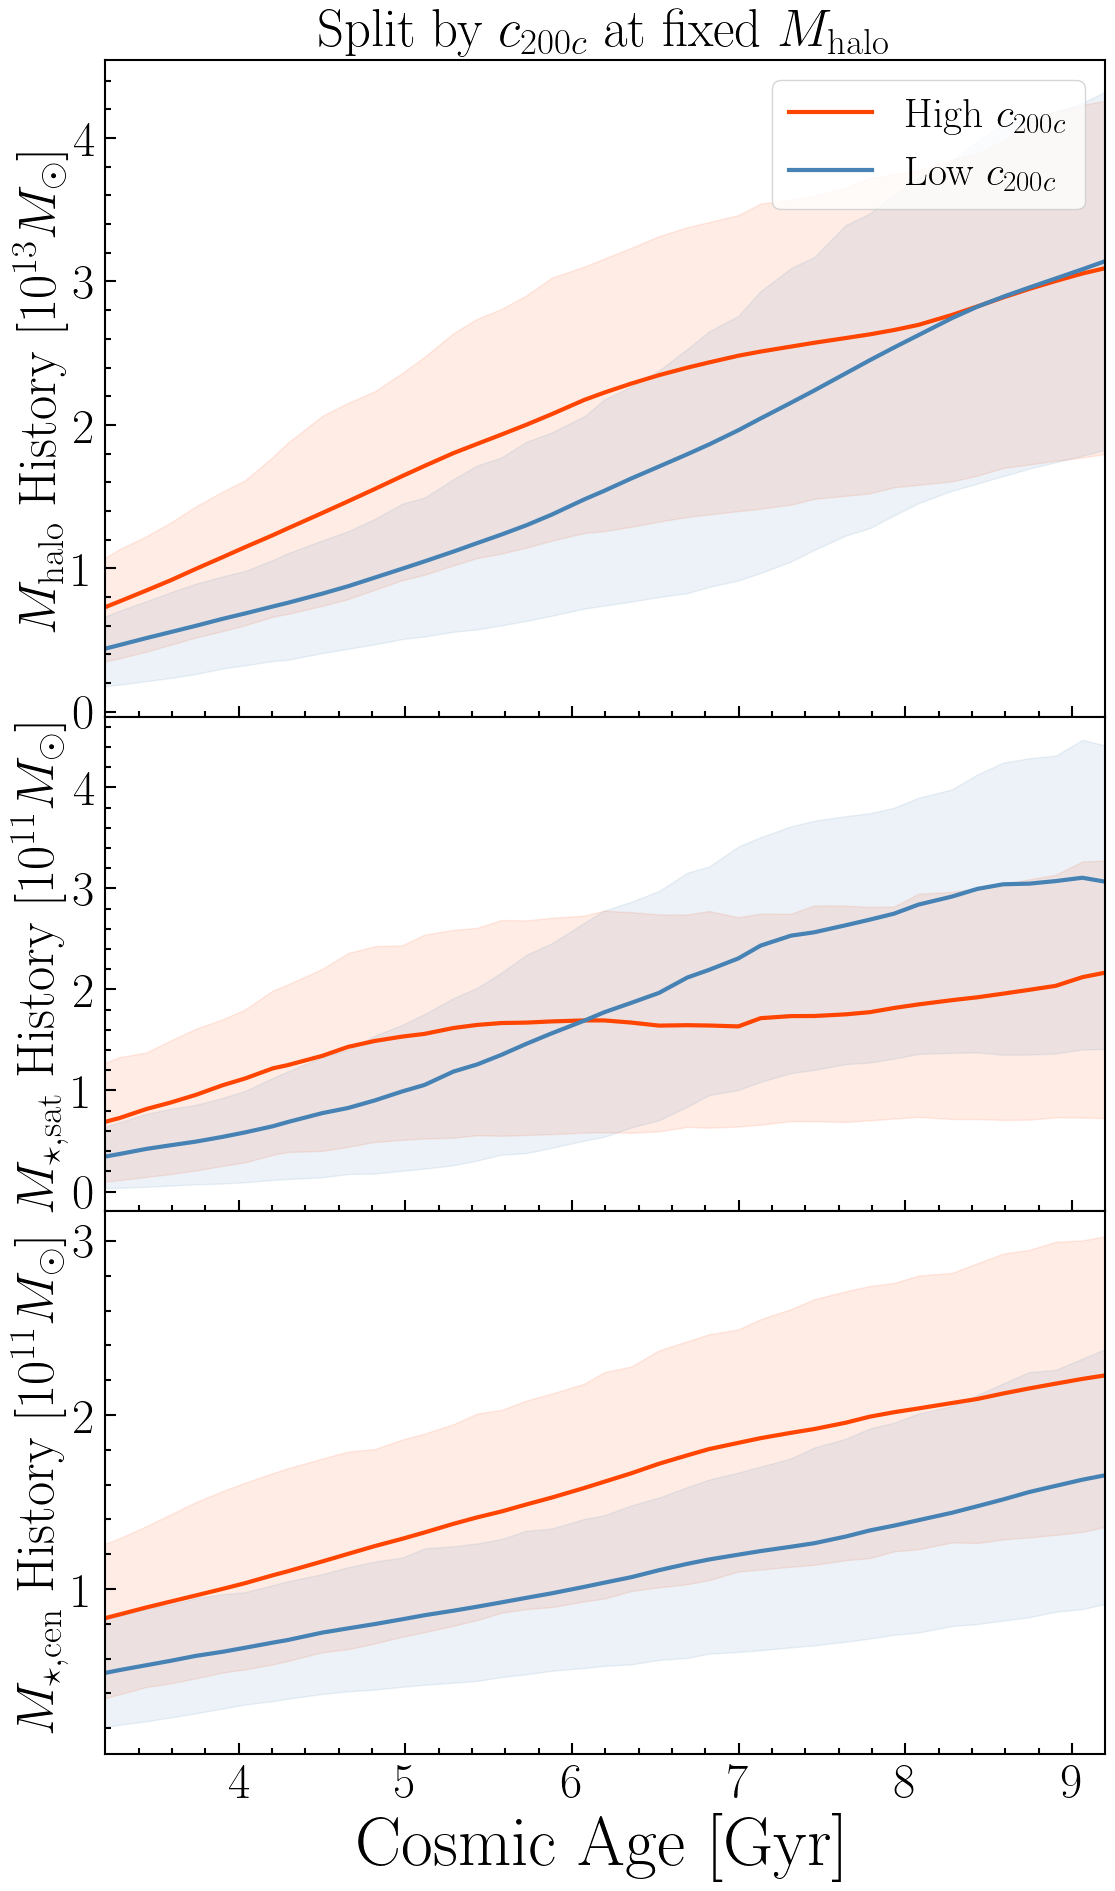

In [81]:
fig=plt.figure(figsize=(10,22))
gs_right = GridSpec(3, 1, left=0, right=1, hspace=0, height_ratios=(0.4,0.3,0.33))  # No vertical space


ax22= fig.add_subplot(gs_right[0])
ax21 = fig.add_subplot(gs_right[1],sharex=ax22)
ax20 = fig.add_subplot(gs_right[2],sharex=ax22)

ax20.plot(age_list,mean_smh_upp/1e11,color='orangered',lw=3,alpha=1)
ax20.plot(age_list,mean_smh_down/1e11,color='steelblue',lw=3,alpha=1)
ax20.fill_between(age_list,upper_smh_upp/1e11,lower_smh_upp/1e11,color='orangered',alpha=0.1)
ax20.fill_between(age_list,upper_smh_down/1e11,lower_smh_down/1e11,color='steelblue',alpha=0.1)

ax21.plot(age_list,mean_msath_upp/1e11,color='orangered',lw=3,alpha=1)
ax21.plot(age_list,mean_msath_down/1e11,color='steelblue',lw=3,alpha=1)
ax21.fill_between(age_list,upper_msath_upp/1e11,lower_msath_upp/1e11,color='orangered',alpha=0.1)
ax21.fill_between(age_list,upper_msath_down/1e11,lower_msath_down/1e11,color='steelblue',alpha=0.1)

ax22.plot(age_list,mean_mah_upp/1e13,color='orangered',lw=3,alpha=1,label=r'{\rm High} $c_{200c}$')
ax22.plot(age_list,mean_mah_down/1e13,color='steelblue',lw=3,alpha=1,label=r'{\rm Low} $c_{200c}$')
ax22.fill_between(age_list,upper_mah_upp/1e13,lower_mah_upp/1e13,color='orangered',alpha=0.1)
ax22.fill_between(age_list,upper_mah_down/1e13,lower_mah_down/1e13,color='steelblue',alpha=0.1)

ax20.set_ylabel(r'\rm $M_{\star,\rm cen}$ {\rm History} $[10^{11} M_\odot]$', fontsize=38)
ax21.set_ylabel(r'\rm $M_{\star,\rm sat}$ {\rm History} $[10^{11} M_\odot]$', fontsize=38)
ax22.set_ylabel(r'\rm $M_{\rm halo}$ {\rm History} $[10^{13} M_\odot]$', fontsize=38)
ax20.set_xlim(3.2,9.2)
ax20.set_xlabel(r'\rm Cosmic Age [Gyr]', fontsize=50)
ax22.set_title(r'\rm Split by $c_{200c}$ at fixed $M_{\rm halo}$', fontsize=38)


ax22.legend(fontsize=30)


plt.savefig(fig_dir+"Fig6F.pdf",dpi=150,bbox_inches='tight')